Create a mask file using a SFS

In [ ]:
import numpy as np
import xarray as xr

# ---------------------------------------------------------
# Get the SFS grid
# ---------------------------------------------------------

zarr_path = "s3://noaa-oar-sfsdev-pds/experiments/beta1/forecast/202603/atm_monthly.zarr"

ds = xr.open_zarr(
    zarr_path,
    storage_options={"anon": True}
)

land = ds["land"].isel(member=0, lead=0)

lat = land.lat.values
lon = land.lon.values

print("Grid shape:", land.shape)
print("Lat:", len(lat))
print("Lon:", len(lon))

Grid shape: (361, 720)
Lat: 361
Lon: 720

Number of grid cells:
Erie: 12
Ontario: 7
Michigan-Huron: 50
Superior: 39


/opt/miniconda3/envs/nbs_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/nbs_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


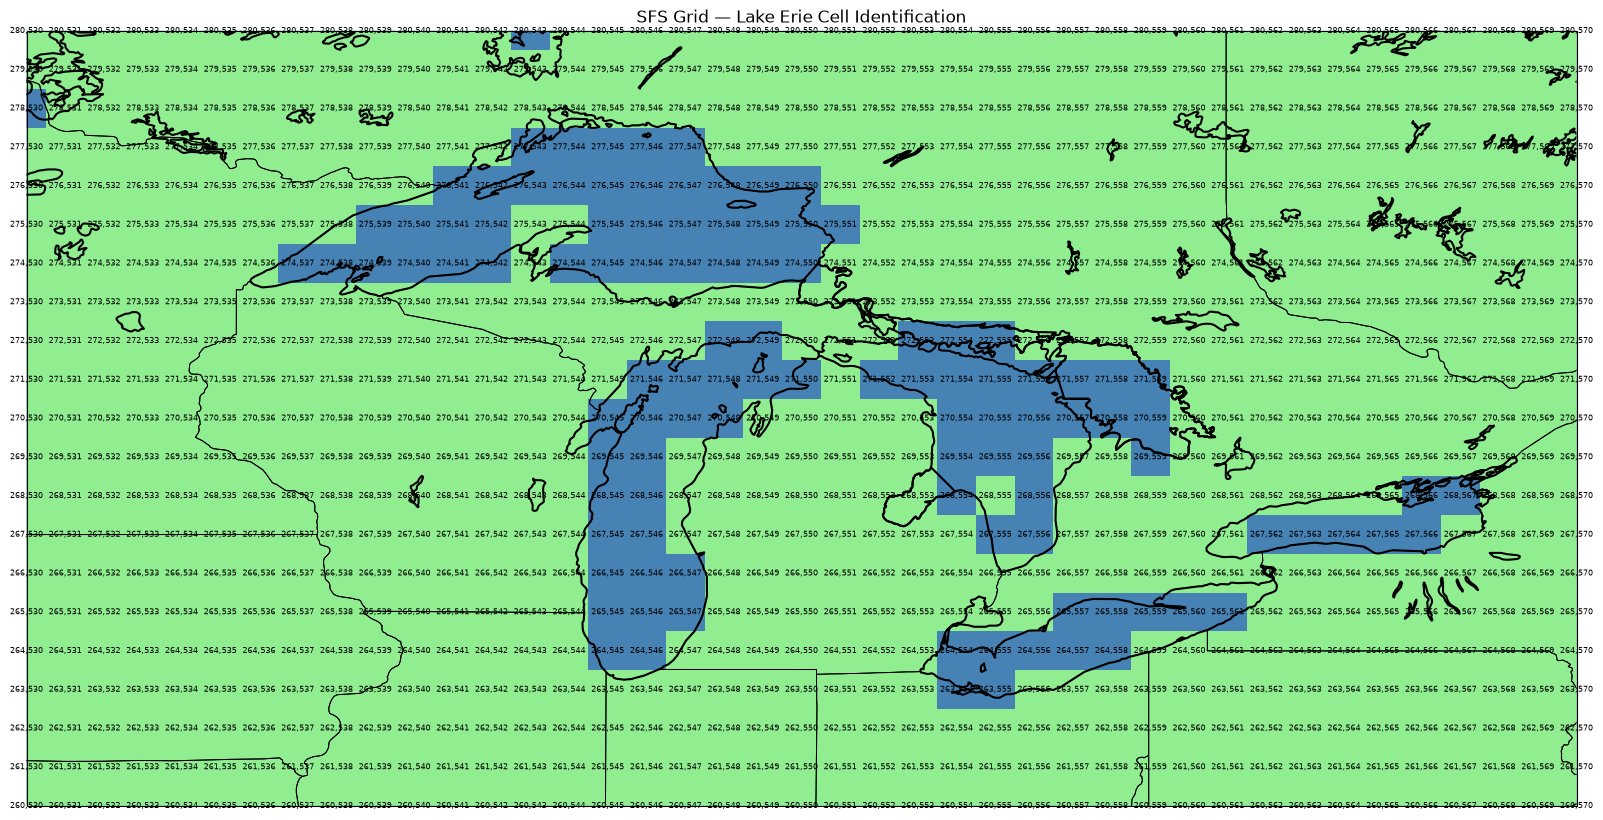

In [29]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import numpy as np

cmap = mcolors.ListedColormap([
    "steelblue",   # 0 = water
    "lightgreen"  # 1 = land
])

# Get coordinates
lat = land.lat.values
lon = land.lon.values

# Convert longitude to -180 to 180 for labeling
lon_180 = ((lon + 180) % 360) - 180

lon2d, lat2d = np.meshgrid(lon_180, lat)

# Create plot
fig = plt.figure(figsize=(20, 15))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot your existing Erie mask
ax.pcolormesh(
    lon_180,
    lat,
    land,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap=cmap
)

# Lake outline
ax.add_feature(
    cfeature.LAKES,
    facecolor="none",
    edgecolor="black",
    linewidth=1.5
)

ax.add_feature(
    cfeature.STATES,
    edgecolor="black",
    linewidth=0.7
)

ax.set_extent(
    [265-360, 285-360, 40, 50],
    crs=ccrs.PlateCarree()
)

# Label every grid point
for i in range(len(lat)):
    for j in range(len(lon)):

        if (
            265-360 <= lon_180[j] <= 285-360
            and 40 <= lat[i] <= 50
        ):
            ax.text(
                lon_180[j],
                lat[i],
                f"{i},{j}",
                fontsize=6,
                ha="center",
                va="center",
                transform=ccrs.PlateCarree(),
                zorder=10
            )

ax.set_title("SFS Grid — Lake Erie Cell Identification")

plt.show()

Create the Lake Masks

This is a tedious, manual step where I used the above plot figure to record the cell x/y and then create variables where those are set to 1 and everything else is set to 0.

In [30]:

# ---------------------------------------------------------
# Function to create a blank mask
# ---------------------------------------------------------

def create_mask(shape):
    return np.zeros(shape, dtype=np.int8)


# ---------------------------------------------------------
# Function to add cells to a mask
# ---------------------------------------------------------

def add_cells(mask, cells):
    """
    Add manually identified grid cells to a mask.

    cells format:
        (row, col)
        (row, col_start, col_end)

    End points are inclusive.
    """

    for cell in cells:

        if len(cell) == 2:
            row, col = cell
            mask[row, col] = 1

        elif len(cell) == 3:
            row, col_start, col_end = cell
            mask[row, col_start:col_end + 1] = 1

        else:
            raise ValueError(f"Invalid cell specification: {cell}")

    return mask


# =========================================================
# ERIE
# =========================================================

erie_cells = [
    (265, 557, 561),
    (264, 554, 558),
    (263, 554, 555),
]

erie_lake = create_mask(land.shape)
erie_lake = add_cells(erie_lake, erie_cells)


# =========================================================
# ONTARIO
# =========================================================

ontario_cells = [
    (268, 566, 567),
    (267, 562, 566),
]

ontario_lake = create_mask(land.shape)
ontario_lake = add_cells(ontario_lake, ontario_cells)


# =========================================================
# MICHIGAN-HURON
# =========================================================

michigan_huron_cells = [
    (272, 548, 549),
    (271, 546, 550),
    (270, 545, 548),
    (269, 545, 546),
    (268, 545, 546),
    (267, 545, 546),
    (266, 545, 547),
    (265, 545, 547),
    (264, 545, 546),

    (272, 553, 555),
    (271, 552, 559),
    (270, 554, 559),
    (269, 554, 556),
    (269, 559),
    (268, 554),
    (268, 556),
    (267, 555, 556),
]

michigan_huron_lake = create_mask(land.shape)
michigan_huron_lake = add_cells(
    michigan_huron_lake,
    michigan_huron_cells
)


# =========================================================
# SUPERIOR
# =========================================================

superior_cells = [
    (277, 543, 547),
    (276, 541, 550),
    (275, 539, 542),
    (275, 545, 551),
    (274, 537, 542),
    (274, 544, 550),
]

superior_lake = create_mask(land.shape)
superior_lake = add_cells(
    superior_lake,
    superior_cells
)


# =========================================================
# CHECK MASKS
# =========================================================

print("\nNumber of grid cells:")
print("Erie:", erie_lake.sum())
print("Ontario:", ontario_lake.sum())
print("Michigan-Huron:", michigan_huron_lake.sum())
print("Superior:", superior_lake.sum())


Number of grid cells:
Erie: 12
Ontario: 7
Michigan-Huron: 50
Superior: 39


Read in Great Lakes Basin shapefile to begin building land masks.

In [31]:
import geopandas as gpd

basin_shapefile = "/Users/ljob/Desktop/Data/shapefiles/shp_wgs84/basin_wgs84.shp"

basins = gpd.read_file(basin_shapefile)

print("\nBasin shapefile:")
print(basins)
print("\nColumns:")
print(basins.columns)

print("\nBasin names:")
for value in basins.iloc[:, 0].unique():
    print(value)


Basin shapefile:
             LAKE    Shape_Leng    Shape_Area  \
0        Superior  7.255686e+06  2.234690e+11   
1  Michigan-Huron  5.592143e+06  1.931878e+11   
2         Ontario  4.024752e+06  8.519949e+10   
3            Erie  4.118557e+06  1.036667e+11   
4           Union  0.000000e+00  0.000000e+00   

                                            geometry  
0  MULTIPOLYGON (((-83.24109 47.65227, -83.24109 ...  
1  MULTIPOLYGON (((-82.04934 42.97588, -82.04897 ...  
2  MULTIPOLYGON (((-79.50362 42.89507, -79.50325 ...  
3  MULTIPOLYGON (((-79.86784 43.0397, -79.86748 4...  
4  POLYGON ((-78.65961 45.69189, -78.6582 45.6897...  

Columns:
Index(['LAKE', 'Shape_Leng', 'Shape_Area', 'geometry'], dtype='str')

Basin names:
Superior
Michigan-Huron
Ontario
Erie
Union


In [32]:
basins = basins.to_crs("EPSG:4326")

basin_name_column = "LAKE"

print(
    basins[basin_name_column].unique()
)


<StringArray>
['Superior', 'Michigan-Huron', 'Ontario', 'Erie', 'Union']
Length: 5, dtype: str


In [ ]:
# Create basin masks

def create_basin_mask(
    basin_geometry,
    grid,
    nlat,
    nlon
):
    """
    Select every SFS grid cell that intersects
    the Great Lakes basin polygon.

    This includes partial cells along basin boundaries.
    """

    # Find grid cells that intersect basin
    selected = grid.intersects(basin_geometry)

    selected_grid = grid[selected]

    mask = np.zeros(
        (nlat, nlon),
        dtype=np.int8
    )

    mask[
        selected_grid["row"].values,
        selected_grid["col"].values
    ] = 1

    return mask

In [ ]:
# To create the land masks by removing the lake masks from the basins

def create_land_mask(
    basin_mask,
    lake_mask,
    sfs_land
):
    """
    Basin land mask.

    1 = land within basin
    0 = outside basin or lake

    Uses:
      basin mask
      SFS land/water mask
      manually defined lake mask
    """

    # Basin AND SFS land
    land_mask = (
        (basin_mask == 1)
        &
        (sfs_land.values == 1)
    )

    # Remove lake cells
    land_mask = (
        land_mask
        &
        (lake_mask == 0)
    )

    return land_mask.astype(np.int8)

In [ ]:
basin_geometries = {
    "superior": basins[
        basins[basin_name_column]
        .str.contains("Superior", case=False, na=False)
    ].geometry.union_all(),

    "michigan-huron": basins[
        basins[basin_name_column]
        .str.contains(
            "Michigan|Huron",
            case=False,
            na=False
        )
    ].geometry.union_all(),

    "erie": basins[
        basins[basin_name_column]
        .str.contains("Erie", case=False, na=False)
    ].geometry.union_all(),

    "ontario": basins[
        basins[basin_name_column]
        .str.contains("Ontario", case=False, na=False)
    ].geometry.union_all()
}


# Corresponding lake masks
lake_masks = {
    "superior": superior_lake,
    "michigan-huron": michigan_huron_lake,
    "erie": erie_lake,
    "ontario": ontario_lake
}

In [ ]:
basin_masks = {}
land_masks = {}

for lake_name, geometry in basin_geometries.items():

    print(f"\nCreating {lake_name} masks...")

    basin_mask = create_basin_mask(
        geometry,
        grid,
        len(lat),
        len(lon)
    )

    basin_masks[lake_name] = basin_mask

    land_masks[lake_name] = create_land_mask(
        basin_mask,
        lake_masks[lake_name],
        land
    )

    print(
        "  Basin cells:",
        basin_mask.sum()
    )

    print(
        "  Lake cells:",
        lake_masks[lake_name].sum()
    )

    print(
        "  Land cells:",
        land_masks[lake_name].sum()
    )

SFS grid:
  Shape: (361, 720)
  Latitude: 361
  Longitude: 720
  Longitude range: 0.0 to 359.5

Original shapefile lakes:
['Superior', 'Michigan-Huron', 'Ontario', 'Erie', 'Union']

Lakes being used:
['Superior', 'Michigan-Huron', 'Ontario', 'Erie']

Basin geometry check:
Superior         valid=True empty=False bounds=(-93.21371980381198, 46.09918057159885, -83.14331412957577, 51.129225936790334)
Michigan-Huron   valid=True empty=False bounds=(-89.71335045744905, 41.26538030768967, -78.47955839765831, 47.60928645578815)
Ontario          valid=True empty=False bounds=(-80.21131073773468, 41.84561602275655, -74.51327255990618, 45.37068160075336)
Erie             valid=True empty=False bounds=(-85.33182748823354, 40.394753573249545, -78.26862604014636, 44.22349116144859)

SFS longitude range:
0.0 359.5
Latitude resolution: 0.5
Longitude resolution: 0.5

Great Lakes grid subset:
  Latitude indices: 256 to 286
  Longitude indices: 520 to 580

Number of Great Lakes grid cells: 1891

Projecti

/opt/miniconda3/envs/nbs_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/nbs_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


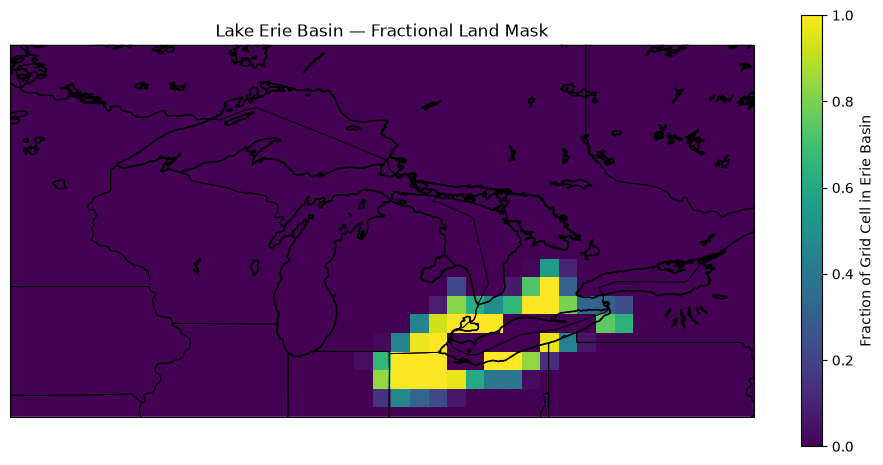

In [ ]:
#### KEEP THIS CELL ######

import numpy as np
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import box

output_file = "SFS_GL_masks.nc"


# =========================================================
# 1. LOAD SFS LAND MASK
# =========================================================

land = ds["land"].isel(
    member=0,
    lead=0
)

lat = land.lat.values
lon = land.lon.values

print("SFS grid:")
print("  Shape:", land.shape)
print("  Latitude:", len(lat))
print("  Longitude:", len(lon))

print(
    "  Longitude range:",
    lon.min(),
    "to",
    lon.max()
)


# =========================================================
# 2. LOAD BASIN SHAPEFILE
# =========================================================

basins = gpd.read_file(
    basin_shapefile
)

print("\nOriginal shapefile lakes:")
print(
    basins["LAKE"].tolist()
)


# =========================================================
# 3. REMOVE UNION (Part of the shapefile for some reason)
# =========================================================

# The Union geometry is invalid and is not needed.
# Only retain the four individual lake basins.

basins = basins[
    basins["LAKE"].isin([
        "Superior",
        "Michigan-Huron",
        "Erie",
        "Ontario"
    ])
].copy()


print("\nLakes being used:")
print(
    basins["LAKE"].tolist()
)


# =========================================================
# 4. CONVERT BASINS TO LAT/LON
# =========================================================

basins = basins.to_crs(
    "EPSG:4326"
)


# =========================================================
# 5. CHECK BASIN GEOMETRIES
# =========================================================

print("\nBasin geometry check:")

for _, row in basins.iterrows():

    print(
        f"{row['LAKE']:16s} "
        f"valid={row.geometry.is_valid} "
        f"empty={row.geometry.is_empty} "
        f"bounds={row.geometry.bounds}"
    )


# =========================================================
# 6. CONVERT AND SORT SFS LONGITUDES
# =========================================================

print("\nSFS longitude range:")
print(lon.min(), lon.max())


# ---------------------------------------------------------
# Calculate grid resolution
# ---------------------------------------------------------

lat_res = abs(lat[1] - lat[0])
lon_res = abs(lon[1] - lon[0])

print("Latitude resolution:", lat_res)
print("Longitude resolution:", lon_res)


# =========================================================
# 7. CREATE ONLY GRID CELLS AROUND GREAT LAKES
# =========================================================

# Instead of creating the entire 361 x 720 grid,
# only create cells around the Great Lakes.
#
# This also avoids projection problems elsewhere
# on the globe.

lon_min = 260
lon_max = 290

lat_min = 38
lat_max = 53


# Find SFS indices in this region

lat_indices = np.where(
    (lat >= lat_min) &
    (lat <= lat_max)
)[0]

lon_indices = np.where(
    (lon >= lon_min) &
    (lon <= lon_max)
)[0]


print(
    "\nGreat Lakes grid subset:"
)

print(
    "  Latitude indices:",
    lat_indices.min(),
    "to",
    lat_indices.max()
)

print(
    "  Longitude indices:",
    lon_indices.min(),
    "to",
    lon_indices.max()
)


# ---------------------------------------------------------
# Calculate edges
# ---------------------------------------------------------

lat_edges = np.concatenate([
    [lat[0] - lat_res / 2],

    (lat[:-1] + lat[1:]) / 2,

    [lat[-1] + lat_res / 2]
])


lon_edges = np.concatenate([
    [lon[0] - lon_res / 2],

    (lon[:-1] + lon[1:]) / 2,

    [lon[-1] + lon_res / 2]
])


# ---------------------------------------------------------
# Create grid polygons
# ---------------------------------------------------------

grid_polygons = []
grid_rows = []
grid_cols = []


for i in lat_indices:

    for j in lon_indices:

        cell = box(
            lon_edges[j],
            lat_edges[i],
            lon_edges[j + 1],
            lat_edges[i + 1]
        )

        grid_polygons.append(cell)

        grid_rows.append(i)

        grid_cols.append(j)


grid = gpd.GeoDataFrame(

    {
        "row": grid_rows,
        "col": grid_cols
    },

    geometry=grid_polygons,

    crs="EPSG:4326"
)


print(
    "\nNumber of Great Lakes grid cells:",
    len(grid)
)


# =========================================================
# 8. PREPARE BASIN GEOMETRIES
# =========================================================

# Shapefile is in -180 to +180 longitude.
#
# SFS is 0-360.
#
# Convert the basin coordinates to 0-360 by using
# a longitude transformation.

def convert_to_360(geom):

    from shapely.ops import transform

    def shift_lon(x, y, z=None):

        x_new = x % 360

        if z is None:
            return x_new, y

        return x_new, y, z

    return transform(
        shift_lon,
        geom
    )


# ---------------------------------------------------------
# Convert basin geometries
# ---------------------------------------------------------

basins_360 = basins.copy()

basins_360["geometry"] = (
    basins_360.geometry.apply(
        convert_to_360
    )
)


# =========================================================
# 9. PROJECT GRID AND BASINS
# =========================================================

print(
    "\nProjecting Great Lakes grid..."
)

grid_area = grid.to_crs(
    "EPSG:5070"
)


print(
    "Checking projected grid..."
)

invalid_projected = (
    ~grid_area.geometry.is_valid
).sum()

print(
    "Invalid projected cells:",
    invalid_projected
)


if invalid_projected > 0:

    print(
        "\nWARNING: Some projected cells are invalid."
    )

    # Repair them
    grid_area["geometry"] = (
        grid_area.geometry.make_valid()
    )


# =========================================================
# 10. FRACTIONAL BASIN FUNCTION
# =========================================================

def create_fractional_basin_mask(
    lake_name
):

    """
    Create fractional basin coverage on the SFS grid.

    0.0 = no basin
    0.25 = 25% basin
    0.50 = 50% basin
    1.0 = entire grid cell
    """

    print(
        f"\nCreating {lake_name} basin mask..."
    )


    # -----------------------------------------------------
    # Get basin
    # -----------------------------------------------------

    basin_geometry = basins_360.loc[
        basins_360["LAKE"] == lake_name,
        "geometry"
    ].iloc[0]


    # -----------------------------------------------------
    # Project basin
    # -----------------------------------------------------

    basin_proj = (
        gpd.GeoSeries(
            [basin_geometry],
            crs="EPSG:4326"
        )
        .to_crs("EPSG:5070")
        .iloc[0]
    )


    # -----------------------------------------------------
    # Repair if necessary
    # -----------------------------------------------------

    if not basin_proj.is_valid:

        print(
            "  Basin geometry invalid -- repairing"
        )

        basin_proj = (
            basin_proj.make_valid()
        )


    # -----------------------------------------------------
    # Find grid cells that intersect basin
    # -----------------------------------------------------

    intersects = (
        grid_area.geometry.intersects(
            basin_proj
        )
    )


    selected = grid_area.loc[
        intersects
    ].copy()


    print(
        "  Intersecting cells:",
        len(selected)
    )


    # -----------------------------------------------------
    # Calculate intersection
    # -----------------------------------------------------

    intersection = (
        selected.geometry.intersection(
            basin_proj
        )
    )


    # -----------------------------------------------------
    # Calculate fractional area
    # -----------------------------------------------------

    selected["fraction"] = (
        intersection.area
        /
        selected.geometry.area
    )


    # -----------------------------------------------------
    # Create full SFS array
    # -----------------------------------------------------

    mask = np.zeros(
        (len(lat), len(lon)),
        dtype=np.float32
    )


    mask[
        selected["row"].values,
        selected["col"].values
    ] = (
        selected["fraction"].values
    )


    return mask

# =========================================================
# 11. CREATE BASIN AND LAND MASKS
# =========================================================

basin_masks = {}
land_masks = {}


for lake_name in [
    "Superior",
    "Michigan-Huron",
    "Erie",
    "Ontario"
]:

    print("\n========================================")
    print(
        f"Processing {lake_name}"
    )
    print("========================================")


    # -----------------------------------------------------
    # Fractional basin mask
    # -----------------------------------------------------

    basin_fraction = (
        create_fractional_basin_mask(
            lake_name
        )
    )


    basin_masks[lake_name] = (
        basin_fraction
    )


    # -----------------------------------------------------
    # Apply SFS land mask
    # -----------------------------------------------------

    basin_land = (
        basin_fraction
        *
        land.values
    )


    # -----------------------------------------------------
    # Remove manually identified lake cells
    # -----------------------------------------------------

    basin_land[
        lake_masks[lake_name] == 1
    ] = 0.0


    land_masks[lake_name] = (
        basin_land.astype(
            np.float32
        )
    )


    # -----------------------------------------------------
    # Summary
    # -----------------------------------------------------

    print(
        "  Basin cells:",
        np.count_nonzero(
            basin_fraction
        )
    )

    print(
        "  Land cells:",
        np.count_nonzero(
            basin_land
        )
    )

    print(
        "  Maximum basin fraction:",
        basin_fraction.max()
    )

# =========================================================
# 12. CREATE FRACTIONAL BASIN MASK
# =========================================================

def create_fractional_basin_mask(
    basin_geometry
):

    """
    Calculate the fraction of each SFS grid cell
    that falls within the basin.

    Values:

        0.0 = no basin

        0.25 = 25% of cell in basin

        0.50 = 50% of cell in basin

        1.0 = entire cell in basin
    """

    # -----------------------------------------------------
    # Project basin to equal-area projection
    # -----------------------------------------------------

    basin_proj = (
        gpd.GeoSeries(
            [basin_geometry],
            crs="EPSG:4326"
        )
        .to_crs("EPSG:5070")
        .iloc[0]
    )


    # -----------------------------------------------------
    # Check basin geometry
    # -----------------------------------------------------

    print(
        "  Basin projected geometry valid:",
        basin_proj.is_valid
    )

    print(
        "  Basin projected geometry empty:",
        basin_proj.is_empty
    )


    # -----------------------------------------------------
    # Use basin bounding box first
    #
    # This avoids testing the entire global SFS grid.
    # -----------------------------------------------------

    minx, miny, maxx, maxy = (
        basin_proj.bounds
    )


    candidate = grid_area[
        grid_area.geometry.bounds.minx <= maxx
    ]

    candidate = candidate[
        candidate.geometry.bounds.maxx >= minx
    ]

    candidate = candidate[
        candidate.geometry.bounds.miny <= maxy
    ]

    candidate = candidate[
        candidate.geometry.bounds.maxy >= miny
    ]


    print(
        "  Candidate grid cells:",
        len(candidate)
    )


    # -----------------------------------------------------
    # Find actual intersections
    # -----------------------------------------------------

    intersects = (
        candidate.geometry.intersects(
            basin_proj
        )
    )


    selected = candidate.loc[
        intersects
    ].copy()


    print(
        "  Intersecting grid cells:",
        len(selected)
    )


    # -----------------------------------------------------
    # Calculate intersection
    # -----------------------------------------------------

    intersection = (
        selected.geometry.intersection(
            basin_proj
        )
    )


    # -----------------------------------------------------
    # Calculate fractional coverage
    # -----------------------------------------------------

    selected["fraction"] = (
        intersection.area
        /
        selected.geometry.area
    )


    # -----------------------------------------------------
    # Create output array
    # -----------------------------------------------------

    mask = np.zeros(
        (len(lat), len(lon)),
        dtype=np.float32
    )


    mask[
        selected["row"].values,
        selected["col"].values
    ] = (
        selected["fraction"].values
    )


    return mask


# =========================================================
# 13. MANUALLY DEFINED LAKE MASKS
# =========================================================

# These should already exist from your previous code:
#
#   superior_lake
#   michigan_huron_lake
#   erie_lake
#   ontario_lake
#
# 1 = lake
# 0 = not lake


lake_masks = {

    "Superior":
        superior_lake,

    "Michigan-Huron":
        michigan_huron_lake,

    "Erie":
        erie_lake,

    "Ontario":
        ontario_lake

}


# =========================================================
# 14. CREATE BASIN AND LAND MASKS
# =========================================================

basin_masks = {}
land_masks = {}


for lake_name in [
    "Superior",
    "Michigan-Huron",
    "Erie",
    "Ontario"
]:

    print("\n========================================")
    print(
        f"Processing {lake_name}"
    )
    print("========================================")


    # -----------------------------------------------------
    # Get basin geometry
    # -----------------------------------------------------

    basin_geometry = basins.loc[
        basins["LAKE"] == lake_name,
        "geometry"
    ].iloc[0]


    # -----------------------------------------------------
    # Create fractional basin mask
    # -----------------------------------------------------

    basin_fraction = (
        create_fractional_basin_mask(
            basin_geometry
        )
    )


    basin_masks[lake_name] = (
        basin_fraction
    )


    # -----------------------------------------------------
    # Apply SFS land mask
    # -----------------------------------------------------

    basin_land = (
        basin_fraction
        *
        land.values
    )


    # -----------------------------------------------------
    # Remove manually identified lake cells
    # -----------------------------------------------------

    basin_land[
        lake_masks[lake_name] == 1
    ] = 0.0


    land_masks[lake_name] = (
        basin_land.astype(
            np.float32
        )
    )


    # -----------------------------------------------------
    # Print summary
    # -----------------------------------------------------

    print(
        "  Lake cells:",
        int(
            lake_masks[lake_name].sum()
        )
    )

    print(
        "  Basin cells:",
        np.count_nonzero(
            basin_fraction
        )
    )

    print(
        "  Land cells:",
        np.count_nonzero(
            basin_land
        )
    )

    print(
        "  Maximum basin fraction:",
        basin_fraction.max()
    )

    print(
        "  Maximum land fraction:",
        basin_land.max()
    )


# =========================================================
# 15. CREATE XARRAY DATASET
# =========================================================

mask_ds = xr.Dataset(

    {

        # -------------------------------------------------
        # SUPERIOR
        # -------------------------------------------------

        "superior_lake": (
            ["lat", "lon"],
            superior_lake.astype(
                np.int8
            )
        ),

        "superior_basin": (
            ["lat", "lon"],
            basin_masks["Superior"]
        ),

        "superior_land": (
            ["lat", "lon"],
            land_masks["Superior"]
        ),


        # -------------------------------------------------
        # MICHIGAN-HURON
        # -------------------------------------------------

        "michigan-huron_lake": (
            ["lat", "lon"],
            michigan_huron_lake.astype(
                np.int8
            )
        ),

        "michigan-huron_basin": (
            ["lat", "lon"],
            basin_masks[
                "Michigan-Huron"
            ]
        ),

        "michigan-huron_land": (
            ["lat", "lon"],
            land_masks[
                "Michigan-Huron"
            ]
        ),


        # -------------------------------------------------
        # ERIE
        # -------------------------------------------------

        "erie_lake": (
            ["lat", "lon"],
            erie_lake.astype(
                np.int8
            )
        ),

        "erie_basin": (
            ["lat", "lon"],
            basin_masks["Erie"]
        ),

        "erie_land": (
            ["lat", "lon"],
            land_masks["Erie"]
        ),


        # -------------------------------------------------
        # ONTARIO
        # -------------------------------------------------

        "ontario_lake": (
            ["lat", "lon"],
            ontario_lake.astype(
                np.int8
            )
        ),

        "ontario_basin": (
            ["lat", "lon"],
            basin_masks["Ontario"]
        ),

        "ontario_land": (
            ["lat", "lon"],
            land_masks["Ontario"]
        )

    },

    coords={
        "lat": lat,
        "lon": lon
    }

)


# =========================================================
# 16. ADD ATTRIBUTES
# =========================================================

for lake_name in [
    "superior",
    "michigan-huron",
    "erie",
    "ontario"
]:

    mask_ds[
        f"{lake_name}_lake"
    ].attrs = {

        "description":
            f"Manually defined SFS grid-cell mask for Lake {lake_name}",

        "values":
            "1 = lake, 0 = not lake"

    }


    mask_ds[
        f"{lake_name}_basin"
    ].attrs = {

        "description":
            f"Fraction of each SFS grid cell within the {lake_name} basin",

        "units":
            "fraction of grid cell",

        "range":
            "0 to 1"

    }


    mask_ds[
        f"{lake_name}_land"
    ].attrs = {

        "description":
            f"Fraction of each SFS grid cell that is land within the {lake_name} basin",

        "units":
            "fraction of grid cell",

        "range":
            "0 to 1"

    }


# =========================================================
# 17. GLOBAL ATTRIBUTES
# =========================================================

mask_ds.attrs = {

    "description":
        "Great Lakes basin, lake, and land masks on the SFS grid",

    "grid":
        "SFS atmospheric grid",

    "basin_source":
        "Great Lakes basin shapefile",

    "basin_method":
        "Fractional grid-cell overlap using EPSG:5070",

    "lake_method":
        "Manually identified SFS grid cells",

    "land_method":
        "SFS land/water mask with manually identified lake cells removed"

}


# =========================================================
# 18. SAVE
# =========================================================

print("\nSaving mask file...")

mask_ds.to_netcdf(
    output_file
)

print(
    "\n========================================"
)

print(
    f"Saved: {output_file}"
)

print(
    "========================================"
)


# =========================================================
# 19. PLOT ERIE LAND FRACTION
# =========================================================

fig = plt.figure(
    figsize=(12, 8)
)

ax = plt.axes(
    projection=ccrs.PlateCarree()
)


im = ax.pcolormesh(

    lon,

    lat,

    land_masks["Erie"],

    transform=ccrs.PlateCarree(),

    shading="auto",

    vmin=0,

    vmax=1
)


# ---------------------------------------------------------
# Map extent
# ---------------------------------------------------------

ax.set_extent(
    [265, 285, 40, 50],
    crs=ccrs.PlateCarree()
)


# ---------------------------------------------------------
# State borders
# ---------------------------------------------------------

ax.add_feature(
    cfeature.STATES,
    edgecolor="black",
    linewidth=0.7
)


# ---------------------------------------------------------
# Country borders
# ---------------------------------------------------------

ax.add_feature(
    cfeature.BORDERS,
    edgecolor="black",
    linewidth=0.8
)


# ---------------------------------------------------------
# Lake outlines
# ---------------------------------------------------------

ax.add_feature(
    cfeature.LAKES,
    facecolor="none",
    edgecolor="black",
    linewidth=1.2
)


# ---------------------------------------------------------
# Coastlines
# ---------------------------------------------------------

ax.coastlines(
    resolution="10m"
)


# ---------------------------------------------------------
# Colorbar
# ---------------------------------------------------------

cbar = plt.colorbar(
    im,
    ax=ax,
    shrink=0.7
)

cbar.set_label(
    "Fraction of Grid Cell in Erie Basin"
)


# ---------------------------------------------------------
# Title
# ---------------------------------------------------------

ax.set_title(
    "Lake Erie Basin — Fractional Land Mask"
)


plt.show()

In [28]:
print("SFS latitude:")
print(lat[:5])
print(lat[-5:])

print("\nMask latitude:")
print(mask_ds.lat.values[:5])
print(mask_ds.lat.values[-5:])

print("\nSFS longitude:")
print(lon[:5])
print(lon[-5:])

print("\nMask longitude:")
print(mask_ds.lon.values[:5])
print(mask_ds.lon.values[-5:])

SFS latitude:
[-90.  -89.5 -89.  -88.5 -88. ]
[88.  88.5 89.  89.5 90. ]

Mask latitude:
[-90.  -89.5 -89.  -88.5 -88. ]
[88.  88.5 89.  89.5 90. ]

SFS longitude:
[0.  0.5 1.  1.5 2. ]
[357.5 358.  358.5 359.  359.5]

Mask longitude:
[0.  0.5 1.  1.5 2. ]
[357.5 358.  358.5 359.  359.5]


Double check the resulting mask file

In [35]:
import xarray as xr
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# File path
# ---------------------------------------------------------
nc_file = "SFS_GL_masks.nc"

# ---------------------------------------------------------
# Open NetCDF
# ---------------------------------------------------------
ds = xr.open_dataset(nc_file)

# Print dataset information
print(ds)

# Print all variables
print("\nVariables:")
for var in ds.data_vars:
    print(f"  {var}: {ds[var].dims} {ds[var].shape}")


<xarray.Dataset> Size: 9MB
Dimensions:               (lat: 361, lon: 720)
Coordinates:
  * lat                   (lat) float64 3kB -90.0 -89.5 -89.0 ... 89.0 89.5 90.0
  * lon                   (lon) float64 6kB 0.0 0.5 1.0 ... 358.5 359.0 359.5
Data variables:
    superior_lake         (lat, lon) int8 260kB ...
    superior_basin        (lat, lon) float32 1MB ...
    superior_land         (lat, lon) float32 1MB ...
    michigan-huron_lake   (lat, lon) int8 260kB ...
    michigan-huron_basin  (lat, lon) float32 1MB ...
    michigan-huron_land   (lat, lon) float32 1MB ...
    erie_lake             (lat, lon) int8 260kB ...
    erie_basin            (lat, lon) float32 1MB ...
    erie_land             (lat, lon) float32 1MB ...
    ontario_lake          (lat, lon) int8 260kB ...
    ontario_basin         (lat, lon) float32 1MB ...
    ontario_land          (lat, lon) float32 1MB ...
Attributes:
    description:   Great Lakes basin, lake, and land masks on the native SFS ...
    grid:    

/var/folders/2w/ddc7n0594ydfswtzw_mmfs6c0000gp/T/ipykernel_48379/924973541.py:92: UserWarning: Adding colorbar to a different Figure <Figure size 1200x800 with 2 Axes> than <Figure size 1200x800 with 2 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(
/opt/miniconda3/envs/nbs_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/nbs_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


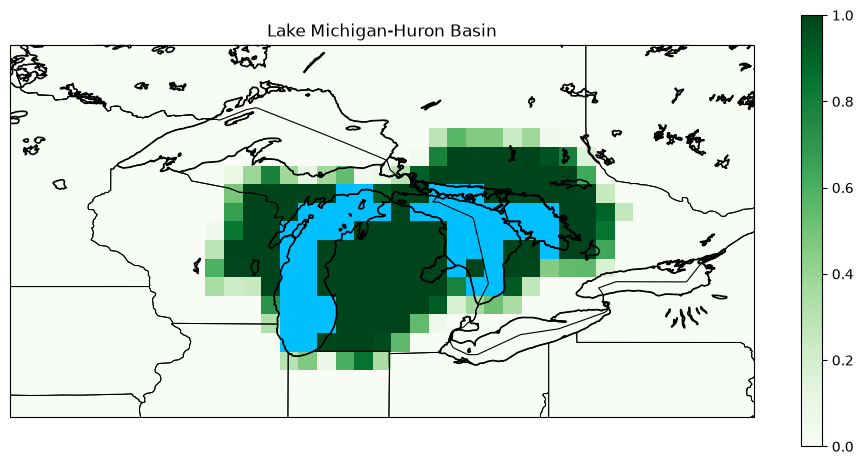

In [57]:
fig = plt.figure(
    figsize=(12, 8)
)

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

# Land mask
ax.pcolormesh(
    lon,
    lat,
    ds['michigan-huron_land'],
    transform=ccrs.PlateCarree(),
    shading="auto",
    vmin=0,
    vmax=1,
    cmap="Greens"
)

# Lake mask — 1 = water, 0 = transparent
lake_cmap = mcolors.ListedColormap(["none", "deepskyblue"])

ax.pcolormesh(
    lon,
    lat,
    ds['michigan-huron_lake'],
    transform=ccrs.PlateCarree(),
    shading="auto",
    vmin=0,
    vmax=1,
    cmap=lake_cmap
)

# ---------------------------------------------------------
# Map extent
# ---------------------------------------------------------

ax.set_extent(
    [265, 285, 40, 50],
    crs=ccrs.PlateCarree()
)


# ---------------------------------------------------------
# State borders
# ---------------------------------------------------------

ax.add_feature(
    cfeature.STATES,
    edgecolor="black",
    linewidth=0.7
)


# ---------------------------------------------------------
# Country borders
# ---------------------------------------------------------

ax.add_feature(
    cfeature.BORDERS,
    edgecolor="black",
    linewidth=0.8
)


# ---------------------------------------------------------
# Lake outlines
# ---------------------------------------------------------

ax.add_feature(
    cfeature.LAKES,
    facecolor="none",
    edgecolor="black",
    linewidth=1.2
)


# ---------------------------------------------------------
# Coastlines
# ---------------------------------------------------------

ax.coastlines(
    resolution="10m"
)


# ---------------------------------------------------------
# Colorbar
# ---------------------------------------------------------

cbar = plt.colorbar(
    im,
    ax=ax,
    shrink=0.7
)

#cbar.set_label(
#    "Fraction of Grid Cell in Erie Basin"
#)


# ---------------------------------------------------------
# Title
# ---------------------------------------------------------

ax.set_title(
    "Lake Michigan-Huron Basin"
)


plt.show()